In [1]:
import sys
print(f"Python: {sys.executable}")
print(f"Version: {sys.version}")

Python: /Users/arinpratapkc/Documents/Projects CS/llm-finetuning-project/venv/bin/python
Version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 11:23:37) [Clang 14.0.6 ]


In [2]:
from datasets import load_dataset

# Stream mode = don't download the whole thing
ds_stream = load_dataset(
    "code-search-net/code_search_net",
    "python",
    split="train",
    streaming=True,
)

print(f"Dataset type: {type(ds_stream)}")
print(f"Features: {ds_stream.features}")

Dataset type: <class 'datasets.iterable_dataset.IterableDataset'>
Features: {'repository_name': Value('string'), 'func_path_in_repository': Value('string'), 'func_name': Value('string'), 'whole_func_string': Value('string'), 'language': Value('string'), 'func_code_string': Value('string'), 'func_code_tokens': List(Value('string')), 'func_documentation_string': Value('string'), 'func_documentation_tokens': List(Value('string')), 'split_name': Value('string'), 'func_code_url': Value('string')}


In [3]:
# Pull the first example
first = next(iter(ds_stream))

print("Keys available:")
for key in first.keys():
    value = first[key]
    if isinstance(value, str):
        preview = value[:100] + "..." if len(value) > 100 else value
        print(f"  {key} (str, len={len(value)}): {preview!r}")
    else:
        print(f"  {key} ({type(value).__name__}): {value}")

Keys available:
  repository_name (str, len=12): 'mjirik/imcut'
  func_path_in_repository (str, len=14): 'imcut/pycut.py'
  func_name (str, len=53): 'ImageGraphCut.__msgc_step3_discontinuity_localization'
  whole_func_string (str, len=2091): 'def __msgc_step3_discontinuity_localization(self):\n        """\n        Estimate discontinuity in bas...'
  language (str, len=6): 'python'
  func_code_string (str, len=2091): 'def __msgc_step3_discontinuity_localization(self):\n        """\n        Estimate discontinuity in bas...'
  func_code_tokens (list): ['def', '__msgc_step3_discontinuity_localization', '(', 'self', ')', ':', 'import', 'scipy', 'start', '=', 'self', '.', '_start_time', 'seg', '=', '1', '-', 'self', '.', 'segmentation', '.', 'astype', '(', 'np', '.', 'int8', ')', 'self', '.', 'stats', '[', '"low level object voxels"', ']', '=', 'np', '.', 'sum', '(', 'seg', ')', 'self', '.', 'stats', '[', '"low level image voxels"', ']', '=', 'np', '.', 'prod', '(', 'seg', '.', 'shape', ')',

In [ ]:
from itertools import islice

# Pull 1000 examples into a list
print("Pulling 1000 examples (takes 30-60 seconds)...")
sample = list(islice(ds_stream, 1000))
print(f"✅ Loaded {len(sample)} examples")

Pulling 1000 examples (takes 30-60 seconds)...


In [ ]:
import pandas as pd

df = pd.DataFrame(sample)
print(f"Shape: {df.shape}")
print(f"\nColumn types:")
print(df.dtypes)
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Shape: (1000, 11)

Column types:
repository_name                 str
func_path_in_repository         str
func_name                       str
whole_func_string               str
language                        str
func_code_string                str
func_code_tokens             object
func_documentation_string       str
func_documentation_tokens    object
split_name                      str
func_code_url                   str
dtype: object

Memory usage: 3.5 MB


In [ ]:
import random

random.seed(42)  # reproducibility
sample_indices = random.sample(range(len(df)), 10)

for i, idx in enumerate(sample_indices):
    row = df.iloc[idx]
    print(f"{'=' * 70}")
    print(f"EXAMPLE {i+1}  (from {row['repository_name']})")
    print(f"Function: {row['func_name']}")
    print(f"{'=' * 70}")
    print(f"\n--- CODE ({len(row['func_code_string'])} chars) ---")
    print(row['func_code_string'][:600])
    if len(row['func_code_string']) > 600:
        print(f"... [truncated, {len(row['func_code_string']) - 600} more chars]")
    print(f"\n--- DOCSTRING ({len(row['func_documentation_string'])} chars) ---")
    print(row['func_documentation_string'])
    print()

EXAMPLE 1  (from varunsrin/one-py)
Function: ONProcess.get_page_content

--- CODE (654 chars) ---
def get_page_content(self, page_id, page_info=0):
        """
          PageInfo
          0 - Returns only basic page content, without selection markup and binary data objects. This is the standard value to pass.
          1 - Returns page content with no selection markup, but with all binary data.
          2 - Returns page content with selection markup, but no binary data.
          3 - Returns page content with selection markup and all binary data.
        """
        try:
            return(self.process.GetPageContent(page_id, "", page_info))
        except Exception as e: 
            pr
... [truncated, 54 more chars]

--- DOCSTRING (384 chars) ---
PageInfo
          0 - Returns only basic page content, without selection markup and binary data objects. This is the standard value to pass.
          1 - Returns page content with no selection markup, but with all binary data.
          

Code length stats:
count     1000.00000
mean       910.01600
std       1381.52817
min        142.00000
10%        258.80000
25%        362.75000
50%        572.00000
75%       1017.25000
90%       1623.70000
95%       2437.45000
max      21304.00000
Name: code_len, dtype: float64

Docstring length stats:
count    1000.000000
mean      179.342000
std       245.030898
min        12.000000
10%        32.000000
25%        49.750000
50%       102.500000
75%       221.500000
90%       435.100000
95%       574.250000
max      4096.000000
Name: doc_len, dtype: float64


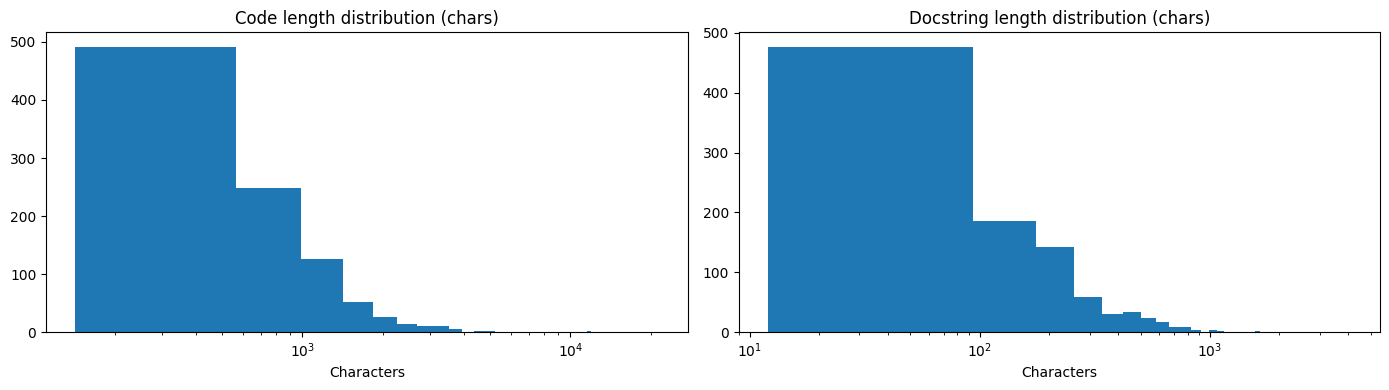

In [ ]:
import matplotlib.pyplot as plt

df['code_len'] = df['func_code_string'].str.len()
df['doc_len'] = df['func_documentation_string'].str.len()

print("Code length stats:")
print(df['code_len'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95]))

print("\nDocstring length stats:")
print(df['doc_len'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95]))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Use log scale for code (huge range)
axes[0].hist(df['code_len'], bins=50)
axes[0].set_title('Code length distribution (chars)')
axes[0].set_xlabel('Characters')
axes[0].set_xscale('log')

axes[1].hist(df['doc_len'], bins=50)
axes[1].set_title('Docstring length distribution (chars)')
axes[1].set_xlabel('Characters')
axes[1].set_xscale('log')

plt.tight_layout()
plt.savefig('../evaluation/data_length_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
# Common garbage indicators in docstrings
df['doc_starts_lowercase'] = df['func_documentation_string'].str.match(r'^[a-z]')
df['doc_has_todo'] = df['func_documentation_string'].str.contains(r'\b(?:TODO|FIXME|XXX|HACK)\b', regex=True, na=False)
df['doc_is_param_only'] = df['func_documentation_string'].str.strip().str.startswith(':param')
df['doc_word_count'] = df['func_documentation_string'].str.split().str.len()
df['doc_has_url'] = df['func_documentation_string'].str.contains(r'https?://', regex=True, na=False)

# Non-ASCII (potential non-English content)
df['doc_has_non_ascii'] = df['func_documentation_string'].apply(
    lambda s: any(ord(c) > 127 for c in s) if isinstance(s, str) else False
)

print("Quality signal counts (out of 1000):")
print(f"  Docstring starts lowercase:     {df['doc_starts_lowercase'].sum():4d}")
print(f"  Contains TODO/FIXME/XXX/HACK:   {df['doc_has_todo'].sum():4d}")
print(f"  Starts with :param (no summary):{df['doc_is_param_only'].sum():4d}")
print(f"  Contains a URL:                  {df['doc_has_url'].sum():4d}")
print(f"  Contains non-ASCII chars:        {df['doc_has_non_ascii'].sum():4d}")
print(f"  Word count < 5:                  {(df['doc_word_count'] < 5).sum():4d}")

Quality signal counts (out of 1000):
  Docstring starts lowercase:       75
  Contains TODO/FIXME/XXX/HACK:      0
  Starts with :param (no summary):   4
  Contains a URL:                    13
  Contains non-ASCII chars:           1
  Word count < 5:                    84


In [ ]:
print("=== TOO-SHORT DOCSTRINGS ===")
short_docs = df[df['doc_word_count'] < 5]
print(f"Count: {len(short_docs)}\n")
for _, row in short_docs.head(5).iterrows():
    print(f"  Function: {row['func_name']}")
    print(f"  Docstring: {row['func_documentation_string']!r}")
    print()

=== TOO-SHORT DOCSTRINGS ===
Count: 84

  Function: MultiscaleArray.mul_block
  Docstring: 'Multiply values in block'

  Function: Variables.expand
  Docstring: 'Expands logical constructions.'

  Function: milestones
  Docstring: 'View/edit/close milestones on github'

  Function: License.get_vector
  Docstring: 'Return pseudo-choice vectors.'

  Function: runcommand
  Docstring: 'Example interface commands'



In [ ]:
print("=== NON-ENGLISH DOCSTRINGS ===")
non_english = df[df['doc_has_non_ascii']]
print(f"Count: {len(non_english)}\n")
for _, row in non_english.head(3).iterrows():
    print(f"  Function: {row['func_name']}")
    print(f"  Docstring: {row['func_documentation_string'][:200]!r}")
    print()

=== NON-ENGLISH DOCSTRINGS ===
Count: 1

  Function: to_dash_case
  Docstring: "Convert a string to dash-delimited words.\n\n    ::\n\n        >>> import uqbar.strings\n        >>> string = 'Tô Đặc Biệt Xe Lửa'\n        >>> print(uqbar.strings.to_dash_case(string))\n        to-dac-biet-"



In [ ]:
print("=== TODO/FIXME DOCSTRINGS ===")
todos = df[df['doc_has_todo']]
print(f"Count: {len(todos)}\n")
for _, row in todos.head(3).iterrows():
    print(f"  Function: {row['func_name']}")
    print(f"  Docstring: {row['func_documentation_string'][:200]!r}")
    print()

=== TODO/FIXME DOCSTRINGS ===
Count: 0



In [ ]:
import re

def passes_filter(row) -> tuple[bool, str]:
    """Returns (passes, reason_if_not). Phase 6 final version."""
    code = row['func_code_string']
    doc = row['func_documentation_string']
    
    if not code or not doc:
        return False, "missing field"
    
    code_len = len(code)
    doc_len = len(doc)
    
    # Length bounds
    if code_len < 100: return False, "code too short"
    if code_len > 2000: return False, "code too long"
    if doc_len < 30: return False, "doc too short"
    if doc_len > 500: return False, "doc too long"
    
    # Word count (adaptive: shorter OK if has formal section)
    words = doc.split()
    has_any_section = bool(re.search(r'\n\s*(?:Args|Returns?|Raises|Yields|Examples?):\s*\n', doc))
    min_words = 5 if has_any_section else 8
    if len(words) < min_words: return False, "too few words in doc"
    
    # Non-ASCII check
    non_ascii = sum(1 for c in doc if ord(c) > 127)
    if non_ascii / max(len(doc), 1) > 0.05: return False, "too much non-ASCII"
    
    # Garbage tokens
    if re.search(r'\b(?:TODO|FIXME|XXX|HACK)\b', doc): 
        return False, "has TODO/FIXME"
    
    # Must start with capital letter
    stripped = doc.strip()
    if not stripped or not stripped[0].isupper(): 
        return False, "doesn't start with capital"
    
    # === Reject non-Google styles ===
    if re.search(r'\n\s*@param\b', doc) or re.search(r'\n\s*@return\b', doc):
        return False, "JavaDoc style (@param/@return)"
    if re.search(r'\n\s*:param\b', doc) or re.search(r'\n\s*:return\b', doc):
        return False, "reStructuredText style (:param/:return)"
    if re.search(r':rtype:', doc):
        return False, "reStructuredText style (:rtype)"
    if re.search(r':raises?:', doc):
        return False, "reStructuredText style (:raises)"
    if re.search(r'\n\s*Parameters\s*\n\s*-+', doc):
        return False, "NumPy style"
    if re.search(r':py:(?:func|class|meth|mod|attr):', doc):
        return False, "Sphinx RST cross-references"
    
    # === Accept Google sections OR clean prose ===
    has_args_section = bool(re.search(r'\n\s*Args:\s*\n', doc))
    has_returns_section = bool(re.search(r'\n\s*Returns?:\s*\n', doc))
    has_raises_section = bool(re.search(r'\n\s*Raises:\s*\n', doc))
    has_google_section = has_args_section or has_returns_section or has_raises_section
    
    lines = stripped.split('\n')
    non_empty_lines = [l for l in lines if l.strip()]
    is_prose_docstring = (
        len(non_empty_lines) <= 4
        and len(stripped) < 400
        and not stripped.endswith(':')
        and not re.search(r'::\s*$', stripped, re.MULTILINE)
    )
    
    if not (has_google_section or is_prose_docstring):
        return False, "not Google-style and not clean prose"
    
    # Sanity-check Args: section has actual content
    if has_args_section:
        args_match = re.search(
            r'\n\s*Args:\s*\n(.*?)(?=\n\s*(?:Returns?|Raises|Yields|Examples?):|$)', 
            doc, re.DOTALL
        )
        if args_match and not re.search(r'^\s+\w+:', args_match.group(1), re.MULTILINE):
            return False, "malformed Args section"
    
    return True, "ok"

In [ ]:
# Apply the updated filter
results = df.apply(passes_filter, axis=1, result_type='expand')
results.columns = ['passes', 'reason']
df['passes_filter'] = results['passes']
df['filter_reason'] = results['reason']

print(f"Total examples: {len(df)}")
print(f"Passed filter:  {df['passes_filter'].sum()} ({100*df['passes_filter'].mean():.1f}%)")
print(f"\nReasons for rejection (top 10):")
print(df[~df['passes_filter']]['filter_reason'].value_counts().head(10))

Total examples: 1000
Passed filter:  265 (26.5%)

Reasons for rejection (top 10):
filter_reason
reStructuredText style (:param/:return)     155
not Google-style and not clean one-liner    141
too few words in doc                        139
doc too short                                75
code too long                                72
doesn't start with capital                   59
doc too long                                 52
JavaDoc style (@param/@return)               28
NumPy style                                   8
Sphinx RST cross-references                   4
Name: count, dtype: int64


In [ ]:
results = df.apply(passes_filter, axis=1, result_type='expand')
results.columns = ['passes', 'reason']
df['passes_filter'] = results['passes']
df['filter_reason'] = results['reason']

print(f"Total examples: {len(df)}")
print(f"Passed filter:  {df['passes_filter'].sum()} ({100*df['passes_filter'].mean():.1f}%)")
print(f"\nRejection reasons:")
print(df[~df['passes_filter']]['filter_reason'].value_counts().head(10))

Total examples: 1000
Passed filter:  355 (35.5%)

Rejection reasons:
filter_reason
reStructuredText style (:param/:return)    155
too few words in doc                       139
doc too short                               75
code too long                               72
doesn't start with capital                  59
doc too long                                52
not Google-style and not clean prose        48
JavaDoc style (@param/@return)              28
NumPy style                                  8
Sphinx RST cross-references                  4
Name: count, dtype: int64


In [ ]:
import random
random.seed(42)

passed = df[df['passes_filter']]
sample_passed = passed.sample(min(6, len(passed)), random_state=42)

for i, (_, row) in enumerate(sample_passed.iterrows(), 1):
    print(f"--- PASSED {i}: {row['func_name']} ---")
    print(f"Code: {len(row['func_code_string'])} chars | Doc: {len(row['func_documentation_string'])} chars")
    print(row['func_documentation_string'])
    print()

--- PASSED 1: class_from_string ---
Code: 243 chars | Doc: 39 chars
Get a python class object from its name

--- PASSED 2: _int_growth ---
Code: 428 chars | Doc: 62 chars
Returns integral of the linear growth factor from z=200 to z=z

--- PASSED 3: Enclosure.mime ---
Code: 261 chars | Doc: 124 chars
Returns the finalised mime object, after
        applying the internal headers. Usually this
        is not to be overriden.

--- PASSED 4: Block.build_act ---
Code: 567 chars | Doc: 101 chars
Act block is a single node - either the act node itself, or the node
        that wraps the act node.

--- PASSED 5: get_related_targetApplication ---
Code: 834 chars | Doc: 141 chars
Return the first matching target application in this version range.
    Returns None if there are no target applications or no matching ones.

--- PASSED 6: award_group_award_id ---
Code: 327 chars | Doc: 91 chars
Find the award group award id, one for each
    item found in the get_funding_group section



In [ ]:
# Show 6 random passed examples, in full
import random
random.seed(123)

passed = df[df['passes_filter']]
print(f"Passed: {len(passed)} examples\n")

sample_passed = passed.sample(6, random_state=42)
for i, (_, row) in enumerate(sample_passed.iterrows(), 1):
    print(f"{'=' * 70}")
    print(f"PASSED EXAMPLE {i}: {row['func_name']}")
    print(f"Code: {len(row['func_code_string'])} chars | Doc: {len(row['func_documentation_string'])} chars")
    print(f"{'=' * 70}")
    print(row['func_documentation_string'])
    print()

Passed: 265 examples

PASSED EXAMPLE 1: Job.async_refresh
Code: 1418 chars | Doc: 48 chars
Trigger an asynchronous job to refresh the cache

PASSED EXAMPLE 2: EnvironmentList.default
Code: 873 chars | Doc: 140 chars
Returns environment marked as default.
            When Zone is set marked default makes no sense, special env with proper Zone is returned.

PASSED EXAMPLE 3: QubellPlatform.get_or_create_organization
Code: 430 chars | Doc: 70 chars
Gets existing or creates new organization
        :rtype: Organization

PASSED EXAMPLE 4: Instance.__collect_interfaces_return
Code: 484 chars | Doc: 60 chars
Collect new style (44.1+) return values to old-style kv-list

PASSED EXAMPLE 5: ServiceRunner.shutdown
Code: 185 chars | Doc: 50 chars
Shutdown the accept loop and stop running payloads

PASSED EXAMPLE 6: load
Code: 328 chars | Doc: 108 chars
Load and parse toml from a file object
    An additional argument `dict_` is used to specify the output type



### Sanity-Check: Spot-Check Rejected Examples

Calibrated filters can throw out good data (false negatives). Spot-checking 
a sample from the largest "borderline" rejection category helps verify the 
filter isn't being too strict.

After the final iteration, this category contains short prose docstrings 
with embedded code blocks (`::` markers) or that exceed the 400-char prose 
limit—rejections we consider correct for output style consistency.

In [ ]:
# Spot-check the borderline rejection category for false negatives
rejected_style = df[df['filter_reason'] == 'not Google-style and not clean prose']
print(f"Rejected as not-Google-style: {len(rejected_style)} examples\n")

sample_rejected = rejected_style.sample(min(4, len(rejected_style)), random_state=42)
for i, (_, row) in enumerate(sample_rejected.iterrows(), 1):
    print(f"--- REJECTED {i}: {row['func_name']} ---")
    print(row['func_documentation_string'])
    print()

Rejected as not-Google-style: 48 examples

--- REJECTED 1: Block.build_assert ---
Assert block is all nodes that are after the Act node.

        Note:
            The filtering is *still* running off the line number of the Act
            node, when instead it should be using the last line of the Act
            block.

--- REJECTED 2: ESBaseView.get_collection_es ---
Get ES objects collection taking into account the generated
        queryset of parent view.

        This method allows working with nested resources properly. Thus a
        queryset returned by this method will be a subset of its parent view's
        queryset, thus filtering out objects that don't belong to the parent
        object.

--- REJECTED 3: Organization.instance ---
Smart method. It does everything, to return Instance with given parameters within the application.
        If instance found running and given parameters are actual: return it.
        If instance found, but parameters differs - reconfigure inst